# Data preprocessing

In [2]:
import torch 

torch.cuda.is_available()

True

In [3]:
!pip install opencv-python -q 

In [4]:
!pip install tqdm pynvml -q 

In [5]:
!pip install imageio -q 

In [62]:
!pip install matplotlib -q 
!pip install requests -q 

In [1]:
import os
import sys
from dotenv import load_dotenv
load_dotenv()

root_dir = os.getenv('PROJECT_ROOT')
root_coco = os.getenv('DATA_DIR')
train_coco = os.getenv('TRAIN_DIR')
val_coco = os.getenv('VAL_DIR')
tokenizer_models_dir = os.getenv('TOK_DIR')

src_dir = os.path.join(root_dir, "src")
train_folder = os.path.join(root_coco, f"{train_coco}")
val_folder = os.path.join(root_coco, f"{val_coco}")
train_ann_file = os.path.join(root_coco, "annotations", f"captions_{train_coco}.json")
val_ann_file = os.path.join(root_coco, "annotations", f"captions_{val_coco}.json")


if src_dir not in sys.path:
    sys.path.insert(0, src_dir)
os.chdir(src_dir)

True

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import DataLoader, Dataset

import os
import cv2
import math
import json
import pickle
import pynvml
import imageio
import os
import json
import requests
from PIL import Image
from io import BytesIO

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime as dt

import matplotlib.gridspec as gridspec
from torchvision.utils import save_image
from IPython.display import clear_output

/home/mahanthyalla/miniconda3/envs/mygpt/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [8]:
# torch.manual_seed(24004) 
# torch.cuda.manual_seed(24004)
# np.random.seed(24004)

In [9]:
def get_best_gpu(verbose = False):
    pynvml.nvmlInit()
    num_gpus = torch.cuda.device_count()

    if num_gpus == 0:
        if verbose :
            print("[!] No CUDA devices found, running on CPU.")
        return 'cpu'

    gpu_mem = []
    for i in range(num_gpus):
        handle = pynvml.nvmlDeviceGetHandleByIndex(i)
        mem_info = pynvml.nvmlDeviceGetMemoryInfo(handle)
        free_mem = mem_info.free
        total_mem = mem_info.total
        if verbose:
            print(f"[+] GPU {i}: Total {total_mem / 1e9:.2f} GB, Free {free_mem / 1e9:.2f} GB")
        gpu_mem.append((i, free_mem))

    gpu_mem.sort(key=lambda x: x[1], reverse=True)

    best_gpu = gpu_mem[0][0]
    second_best_gpu = gpu_mem[1][0] if len(gpu_mem) > 1 else best_gpu

    selected_gpu = second_best_gpu if best_gpu == 0 else best_gpu

    pynvml.nvmlShutdown()
    return selected_gpu

def set_gpu(verbose = False):
    device_active = 'cuda' if torch.cuda.is_available() else 'cpu'
    if device_active == 'cuda':
        if verbose:
            print('[+] CUDA : available')
        try:
            GPU_NUMBER = get_best_gpu(verbose)
            if verbose:
                print(f'[>] Current Device {torch.cuda.current_device()} -> changing it to {GPU_NUMBER}')
            torch.cuda.set_device(GPU_NUMBER)
            if verbose:
                print(f'[+] Current Device {torch.cuda.current_device()}')
        except Exception as e:
            if verbose:
                print(f'[-] Error Occured while changing GPU ! \n\n\tERROR :{e}\n\n')
                print(f'[!] CUDA ERR : Couldn\'t change  -> using CPU {device_active = }')
        finally: 
            pass
        print(f'[>] device = cuda:{GPU_NUMBER}')
    else :
        if verbose:
            print(f'[!] CUDA ERR : Not available -> using CPU {device_active = }')
        print(f'[>] device = cpu')

set_gpu()

[>] device = cuda:1


COCO :

#### Training images (~18GB)
```
nohup wget http://images.cocodataset.org/zips/train2017.zip  > train2017.log 2>&1 &
```
#### Validation images (~1GB)
```
nohup wget http://images.cocodataset.org/zips/val2017.zip > val2017.log 2>&1 &
```
#### Test images (~7GB) (optional, no captions)
```
nohup wget http://images.cocodataset.org/zips/test2017.zip > test2017.log 2>&1 &
```
#### Captions and detection annotations (~250MB)
```
nohup wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip > annotations_trainval2017.log 2>&1 &
```

```
unzip train2017.zip
unzip val2017.zip
unzip test2017.zip   # optional
unzip annotations_trainval2017.zip
```

In [3]:
ann_file = train_ann_file

In [4]:
with open(ann_file, 'r') as f:
    data = json.load(f)

In [5]:
data.keys()

dict_keys(['info', 'licenses', 'images', 'annotations'])

In [6]:
len(data['images'])
len(data['annotations'])

118287

591753

In [7]:
idx = 44
img_id = data['annotations'][idx]['image_id']
img_id

382406

In [8]:
for img in data['images']:
    if img_id == img['id']:
        image = img
        break
image

{'license': 1,
 'file_name': '000000382406.jpg',
 'coco_url': 'http://images.cocodataset.org/train2017/000000382406.jpg',
 'height': 413,
 'width': 640,
 'date_captured': '2013-11-15 08:03:55',
 'flickr_url': 'http://farm3.staticflickr.com/2291/2392526741_f0f7b6f5e7_z.jpg',
 'id': 382406}

In [9]:
captions = []
for cap in data['annotations']:
    if img_id == cap['image_id']:
        captions.append(cap)
captions

[{'image_id': 382406,
  'id': 1221,
  'caption': 'A woman is walking a dog in the city.'},
 {'image_id': 382406,
  'id': 1620,
  'caption': 'A woman and her dog walking down a sidewalk next to a fence with some flowers. '},
 {'image_id': 382406,
  'id': 2091,
  'caption': 'A woman walking her dog on the sidewalk.'},
 {'image_id': 382406,
  'id': 3237,
  'caption': 'A woman walks her dog along a city street.'},
 {'image_id': 382406,
  'id': 7911,
  'caption': 'A woman walks her dog on a city sidewalk.'}]

In [12]:
# all_captions = []
caption_lens = []
for cap in data['annotations']:
    # all_captions.append(cap)
    caption_lens.append(len(cap['caption'].split()))
# all_captions
len(caption_lens)

591753

In [15]:
all_cap_lens =  np.array(caption_lens)
all_cap_lens.min(), all_cap_lens.max()
all_cap_lens.mean()

(np.int64(5), np.int64(49))

np.float64(10.457178924314706)

'000000382406.jpg'

(np.float64(-0.5), np.float64(639.5), np.float64(412.5), np.float64(-0.5))

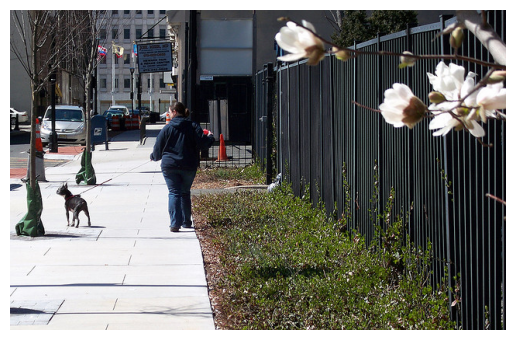

In [117]:
image['coco_url'].split('/')[-1]

img_path = os.path.join(train_folder, image['coco_url'].split('/')[-1]) 
img_ = plt.imread(img_path)

plt.imshow(img_)
plt.axis("off")
plt.show()

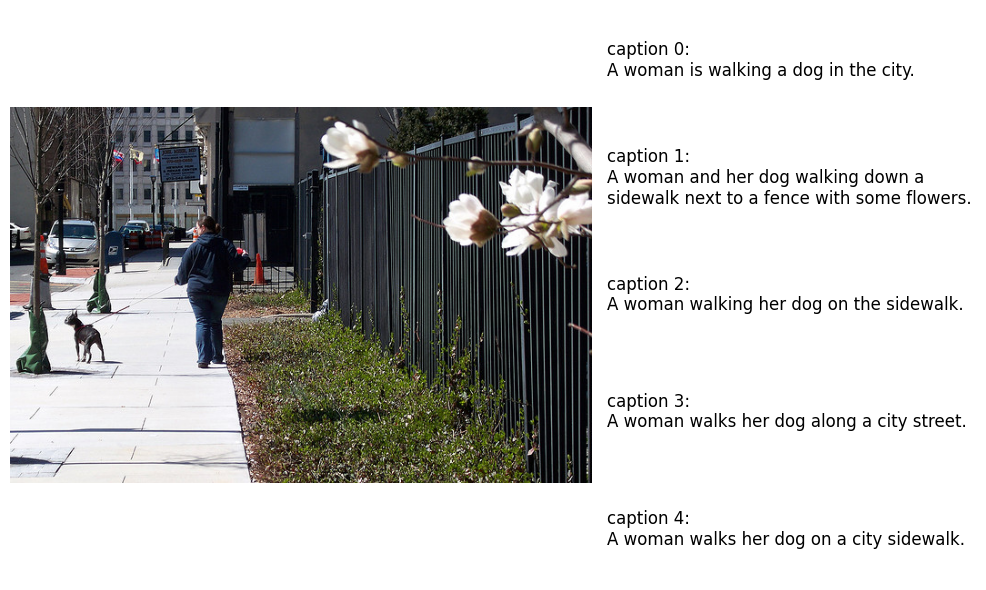

In [118]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(5, 2, width_ratios=[2, 1])

ax0 = plt.subplot(gs[:, 0])
_ = ax0.imshow(img_)
_ = ax0.axis("off")

for i, caption in enumerate(captions):
    ax = plt.subplot(gs[i, 1])
    _ = ax.axis("off")
    _ = ax.text(0, 0.5, f"caption {i}:\n{caption['caption']}", fontsize=12, va="center", wrap=True)

plt.tight_layout()
plt.show()

## DATASET

In [ ]:

class COCODataset(Dataset):
    def __init__(self, root, ann_file, transform=None):
        self.root = root
        self.transform = transform
        
        with open(ann_file, 'r') as f:
            data = json.load(f)
        
        self.images = {img['id']: img for img in data['images']}
        self.annotations = data['annotations']
    
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_info = self.images[ann['image_id']]
        
        img_path = os.path.join(self.root, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        caption = ann['caption']
        
        return image, caption


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [19]:
dataset = COCODataset(train_folder, ann_file, transform=transform)

In [20]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=4)

In [ ]:
for images, captions in dataloader:
    print("Batch of images:", images.shape)
    print("Batch of captions:", captions[:1])
    break

Batch of images: torch.Size([16, 3, 224, 224])
Batch of captions: ('Two dogs poking their heads through curtains at windows.', 'a couple of zebras standing next to each other and looking towards the camera ', 'The man is playing a video game in his living room.')


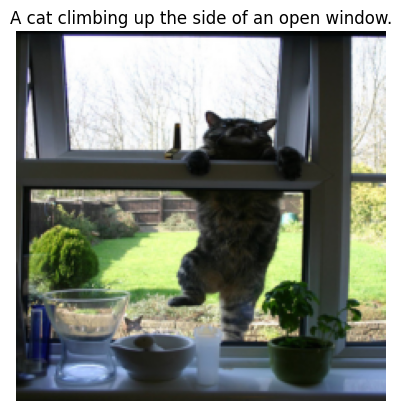

In [109]:
idx = 8
_ = plt.imshow(images[idx].permute(1,2,0))
_ = plt.title(captions[idx])
_ = plt.axis('off')

In [119]:
len(dataset)

591753

# TOKENIZER

In [1]:
!pip install datasets -q

# Data for tokenizer

In [2]:
from datasets import load_dataset
pg = load_dataset("rojagtap/bookcorpus", split="train")

/home/mahanthyalla/miniconda3/envs/mygpt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from tqdm import tqdm

In [4]:
pg.shape

(74004228, 1)

In [45]:
idx = 0
pg['text'][idx]

'the half-ling book one in the fall of igneeria series kaylee soderburg copyright 2013 kaylee soderburg all rights reserved .'

In [ ]:
import re

# isbn: 1492913731 isbn-13: 978-1492913733

def preprocess(text:str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9'.,!?;:()\-\s]", " ", text)
    text = re.sub(r"isbn\s?:\s?[0-9]+", " ", text) 
    text = re.sub(r"isbn\s?-[0-9]+\s?:\s?[0-9]+\-?[0-9]+", " ", text) 
    text = re.sub(r"copyright\s+[0-9]+[\w\s]+all rights reserved", " ", text) 
    text = re.sub(r"copyright\s+[0-9]+", " ", text) 
    text = re.sub(r"all rights reserved", " ", text) 
    text = re.sub(r"\s+([.,:;!@#$*+\-\'\"|=?])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

preprocess(pg['text'][idx])

'the half-ling book one in the fall of igneeria series kaylee soderburg.'

In [59]:
samples = 250_000

In [ ]:
book_txts = ''
with open(f"{tokenizer_models_dir}/books_dataset_preprocessed.txt", "w", encoding="utf-8") as f:
    i = 0
    for ex in tqdm(pg,total=samples,):
        if "text" in ex:
            processed_txt = preprocess(ex["text"]) + ' '
            book_txts += processed_txt
            _ = f.write(processed_txt)
        elif "texts" in ex:
            processed_txt = preprocess(ex["texts"]) + ' '
            book_txts += processed_txt
            _ = f.write(processed_txt)
        elif "book_text" in ex:
            processed_txt = preprocess(ex["book_text"]) + ' '
            book_txts += processed_txt
            _ = f.write(processed_txt)
        else:
            continue
        i+=1
        if i >= samples:
            break


100%|█████████▉| 249999/250000 [05:46<00:00, 720.76it/s] 


In [3]:
with open(f"{tokenizer_models_dir}/train_caps.txt", encoding='utf-8') as f :
    coco_txt = f.read()

In [62]:
len(coco_txt), len(book_txts)

(31554125, 17960745)

In [63]:
all_txt = coco_txt + book_txts
unq_words = set(all_txt.split())
len(unq_words)

124136

In [4]:
from datasets.tokenizer import myTokenizer_faster

TOKEN_UNK = '<|unknown|>'
TOKEN_SOS = '<|startofseq|>'
TOKEN_EOS = '<|endofseq|>'
TOKEN_PAD = '<|padding|>'
TOKEN_END = '<|endoftext|>'

In [5]:

vocab_size = 8192
tokenizer = myTokenizer_faster(
    token_model_file=f"{tokenizer_models_dir}/bpe{vocab_size}.model",
    special_tokens={
        TOKEN_UNK : vocab_size - 5,
        TOKEN_SOS : vocab_size - 4,
        TOKEN_EOS : vocab_size - 3,
        TOKEN_PAD : vocab_size - 2,
        TOKEN_END : vocab_size - 1
    } 
)

tokenizer._vocab_size()

261

In [6]:
# tokenizer.train(all_txt, vocab_size)

In [7]:
vocab = tokenizer.load()
tokenizer.encode('Hi This is Mahanth')

Loaded 7419 merges, 5 specials, 512 protected
Total vocabulary size: 8192


[72, 105, 32, 84, 851, 288, 32, 77, 97, 104, 97, 823, 104]

In [8]:
tokenizer.decode(tokenizer.encode('Hi This is Mahanth'))

'Hi This is Mahanth'